In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
import optuna
from catboost import CatBoostClassifier, Pool, cv
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize, StandardScaler, TargetEncoder
import glob
import os
from pathlib import Path
from google.colab import drive
drive.mount('/content/drive')

In [2]:
df_train = pd.read_csv('/content/drive/My Drive/Colab Notebooks/shift_ml_2026_train.csv')
X_test_base = pd.read_csv('/content/drive/My Drive/Colab Notebooks/shift_ml_2026_test.csv')
X_test_base['Test'] = 1
df_all = pd.concat([df_train, X_test_base], ignore_index=True) # Объединение тестовой и тренировочный выборок для добавления новых признаков

/tmp/ipython-input-2840701043.py:1: DtypeWarning: Columns (49) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train = pd.read_csv('/content/drive/My Drive/Colab Notebooks/shift_ml_2026_train.csv')


### Разведочный анализ данных

In [3]:
cols_num = list(X_test_base.select_dtypes(exclude='object').columns)
cols_str = list(X_test_base.select_dtypes(include='object').columns)
X_test_base[cols_num].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134531 entries, 0 to 134530
Data columns (total 91 columns):
 #   Column                                                            Non-Null Count   Dtype  
---  ------                                                            --------------   -----  
 0   id                                                                134531 non-null  int64  
 1   сумма_займа                                                       134531 non-null  float64
 2   процентная_ставка                                                 134531 non-null  float64
 3   аннуитет                                                          134531 non-null  float64
 4   годовой_доход                                                     134531 non-null  float64
 5   рейтинг_OCR                                                       134531 non-null  int64  
 6   коэфф_акционных_зачислений_в_остатке                              134531 non-null  float64
 7   кол_во_субсидий_за_г

In [4]:
cols_num = list(df_train.select_dtypes(exclude='object').columns)
cols_str = list(df_train.select_dtypes(include='object').columns)
df_train[cols_num].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1210779 entries, 0 to 1210778
Data columns (total 90 columns):
 #   Column                                                            Non-Null Count    Dtype  
---  ------                                                            --------------    -----  
 0   id                                                                1210779 non-null  int64  
 1   сумма_займа                                                       1210779 non-null  float64
 2   процентная_ставка                                                 1210779 non-null  float64
 3   аннуитет                                                          1210779 non-null  float64
 4   годовой_доход                                                     1210779 non-null  float64
 5   итоговый_статус_займа                                             1210779 non-null  int64  
 6   рейтинг_OCR                                                       1210779 non-null  int64  
 7   коэфф_акц

В данных присутствует довольно много пропусков. 
Уберем признаки и строки, в которых пропущено более 50% значений

In [3]:
na_df_t = X_test_base.isna().sum()/X_test_base.shape[0]
na_df_t = na_df_t.reset_index()
to_drop = na_df_t[na_df_t.iloc[:,1] > 0.5].sort_values(by=[0], ascending=False)['index'].to_list()
na_df = df_train.isna().sum()/df_train.shape[0]
na_df = na_df.reset_index()
to_drop_train = na_df[na_df.iloc[:,1] > 0.5].sort_values(by=[0], ascending=False)['index'].to_list()

to_drop_final = list(set(to_drop + to_drop_train))
cols_to_keep = [item for item in df_train.columns if item not in to_drop_final]

na_df = df_train.isna().sum(axis=1)/df_train.shape[1]
na_df = na_df.reset_index()
to_drop_index = na_df[na_df.iloc[:,1] > 0.5]['index'].to_list()
df_all = df_all.drop(index = to_drop_index).reset_index(drop=True).copy()

df_all[cols_to_keep]

,id,сумма_займа,срок_займа,процентная_ставка,аннуитет,рейтинг,допрейтинг,профессия_заемщика,стаж,владение_жильем,...,процент_счетов_без_просрочек,процент_счетов_прев_75_лимита,кол-во_публ_банкротств,кол-во_залогов,кредитный_лимит,кредитный_баланс_без_ипотеки,лимит_по_картам,лимит_по_аннуитетным_счетам,особая_ситуация,тип_предоставления_кредита
0,68355089,1235000.0,3 года,11.99,41014.0,В,В1,инженер,10+ лет,ИПОТЕКА,...,97.4,7.7,0.0,0.0,15700850.0,1973750.0,3965000.0,1233350.0,Нет,Наличные
1,68341763,1000000.0,5 лет,10.78,21633.0,Б,Б4,водитель грузовика,10+ лет,ИПОТЕКА,...,100.0,50.0,0.0,0.0,10920900.0,934800.0,310000.0,743850.0,Нет,Наличные
2,68426831,597500.0,3 года,13.44,20259.0,В,В3,ветеринарный техник,4 года,АРЕНДА,...,100.0,100.0,0.0,0.0,845000.0,639900.0,470000.0,200000.0,Нет,Наличные
3,68476668,1000000.0,3 года,9.17,31879.0,Б,Б2,вице-президент операций по набору персонала,10+ лет,ИПОТЕКА,...,96.3,100.0,0.0,0.0,19442600.0,5838100.0,1575000.0,2322600.0,Нет,Наличные
4,67275481,1000000.0,3 года,8.49,31563.0,Б,Б1,дорожному водителю,10+ лет,ИПОТЕКА,...,93.3,0.0,0.0,0.0,9669500.0,1396850.0,725000.0,1807200.0,Нет,Наличные
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1302818,72082596,280000.0,3 года,13.67,9525.0,В,В3,хирургические продажи,4 года,АРЕНДА,...,100.0,75.0,0.0,0.0,2707300.0,2544500.0,425000.0,2282300.0,Нет,Наличные
1302819,484702,700000.0,3 года,10.25,22669.5,Б,Б2,&quot; е2 инк. &quot;,4 года,АРЕНДА,...,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,Нет,Наличные
1302820,73273241,1500000.0,3 года,12.99,50534.0,В,В2,сертифицированный сотрудник по финансовому пла...,10+ лет,АРЕНДА,...,97.2,40.0,0.0,0.0,5205950.0,4358850.0,950000.0,3780950.0,Нет,Наличные
1302821,50466330,1070000.0,3 года,15.61,37412.5,Г,Г1,владелец,10+ лет,ИПОТЕКА,...,92.9,66.7,0.0,0.0,7753200.0,645700.0,670000.0,0.0,Нет,Наличные


#### Корреляционный анализ

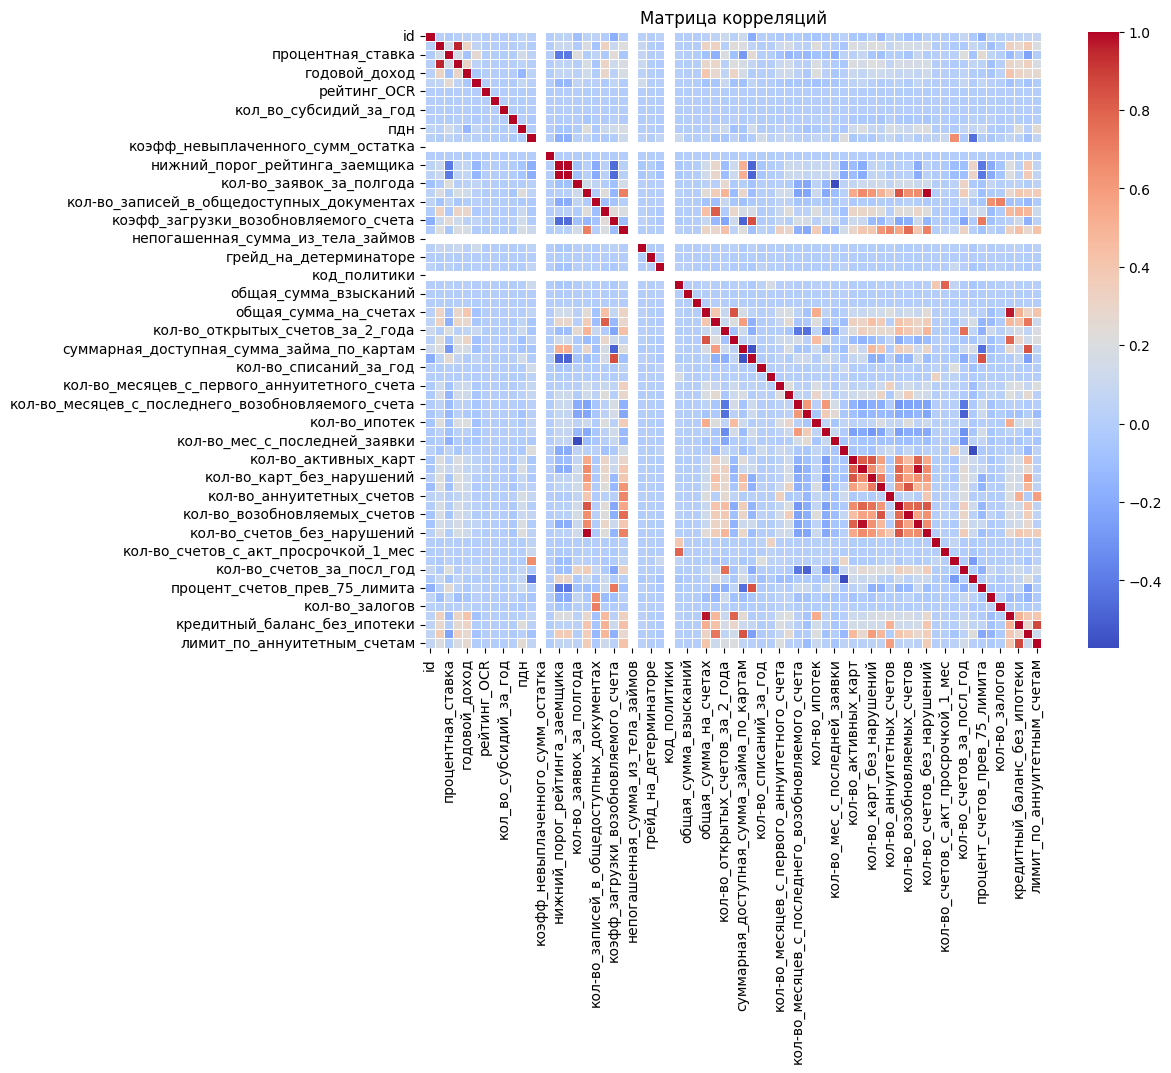


Сильно коррелированные пары (|corr| > 0.95):
  сумма_займа - аннуитет: 0.953
  нижний_порог_рейтинга_заемщика - верхний_порог_рейтинга_заемщика: 1.000
  кол-во_открытых_счетов - кол-во_счетов_без_нарушений: 0.999
  общая_сумма_на_счетах - кредитный_лимит: 0.973
  кол-во_активных_возобновляемых_счетов - кол-во_возобновляемых_счетов_с_балансом_более_0: 0.982


In [4]:
def plot_correlation_matrix(df, threshold=0.8):
    
    corr_matrix = df.corr()
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_matrix, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
    plt.title('Матрица корреляций')
    plt.show()
    
    strong_corr = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                strong_corr.append((
                    corr_matrix.columns[i],
                    corr_matrix.columns[j],
                    corr_matrix.iloc[i, j]
                ))
    
    print(f"\nСильно коррелированные пары (|corr| > {threshold}):")
    for f1, f2, corr in strong_corr:
        print(f"  {f1} - {f2}: {corr:.3f}")
    
    return corr_matrix, strong_corr

cols_num = list(df_train[cols_to_keep].select_dtypes(exclude='object').columns)

corr_matrix, strong_pairs = plot_correlation_matrix(df_train[cols_num], threshold=0.95)

In [5]:
corr_features = []

for f1, f2, corr in strong_pairs:
    corr_features.append([f1,f2])

In [6]:
flat_list = sum(corr_features, [])
df_train[flat_list].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1210779 entries, 0 to 1210778
Data columns (total 10 columns):
 #   Column                                           Non-Null Count    Dtype  
---  ------                                           --------------    -----  
 0   сумма_займа                                      1210779 non-null  float64
 1   аннуитет                                         1210779 non-null  float64
 2   нижний_порог_рейтинга_заемщика                   1210779 non-null  float64
 3   верхний_порог_рейтинга_заемщика                  1210779 non-null  float64
 4   кол-во_открытых_счетов                           1210779 non-null  float64
 5   кол-во_счетов_без_нарушений                      1160572 non-null  float64
 6   общая_сумма_на_счетах                            1150012 non-null  float64
 7   кредитный_лимит                                  1150012 non-null  float64
 8   кол-во_активных_возобновляемых_счетов            1150012 non-null  float64
 9   ко

Исключаем признаки с высокой корреляцией

In [7]:
corr_drop = []

for f1, f2, corr in strong_pairs:
    corr_drop += [f2]

#### Графическое предстваление признаков

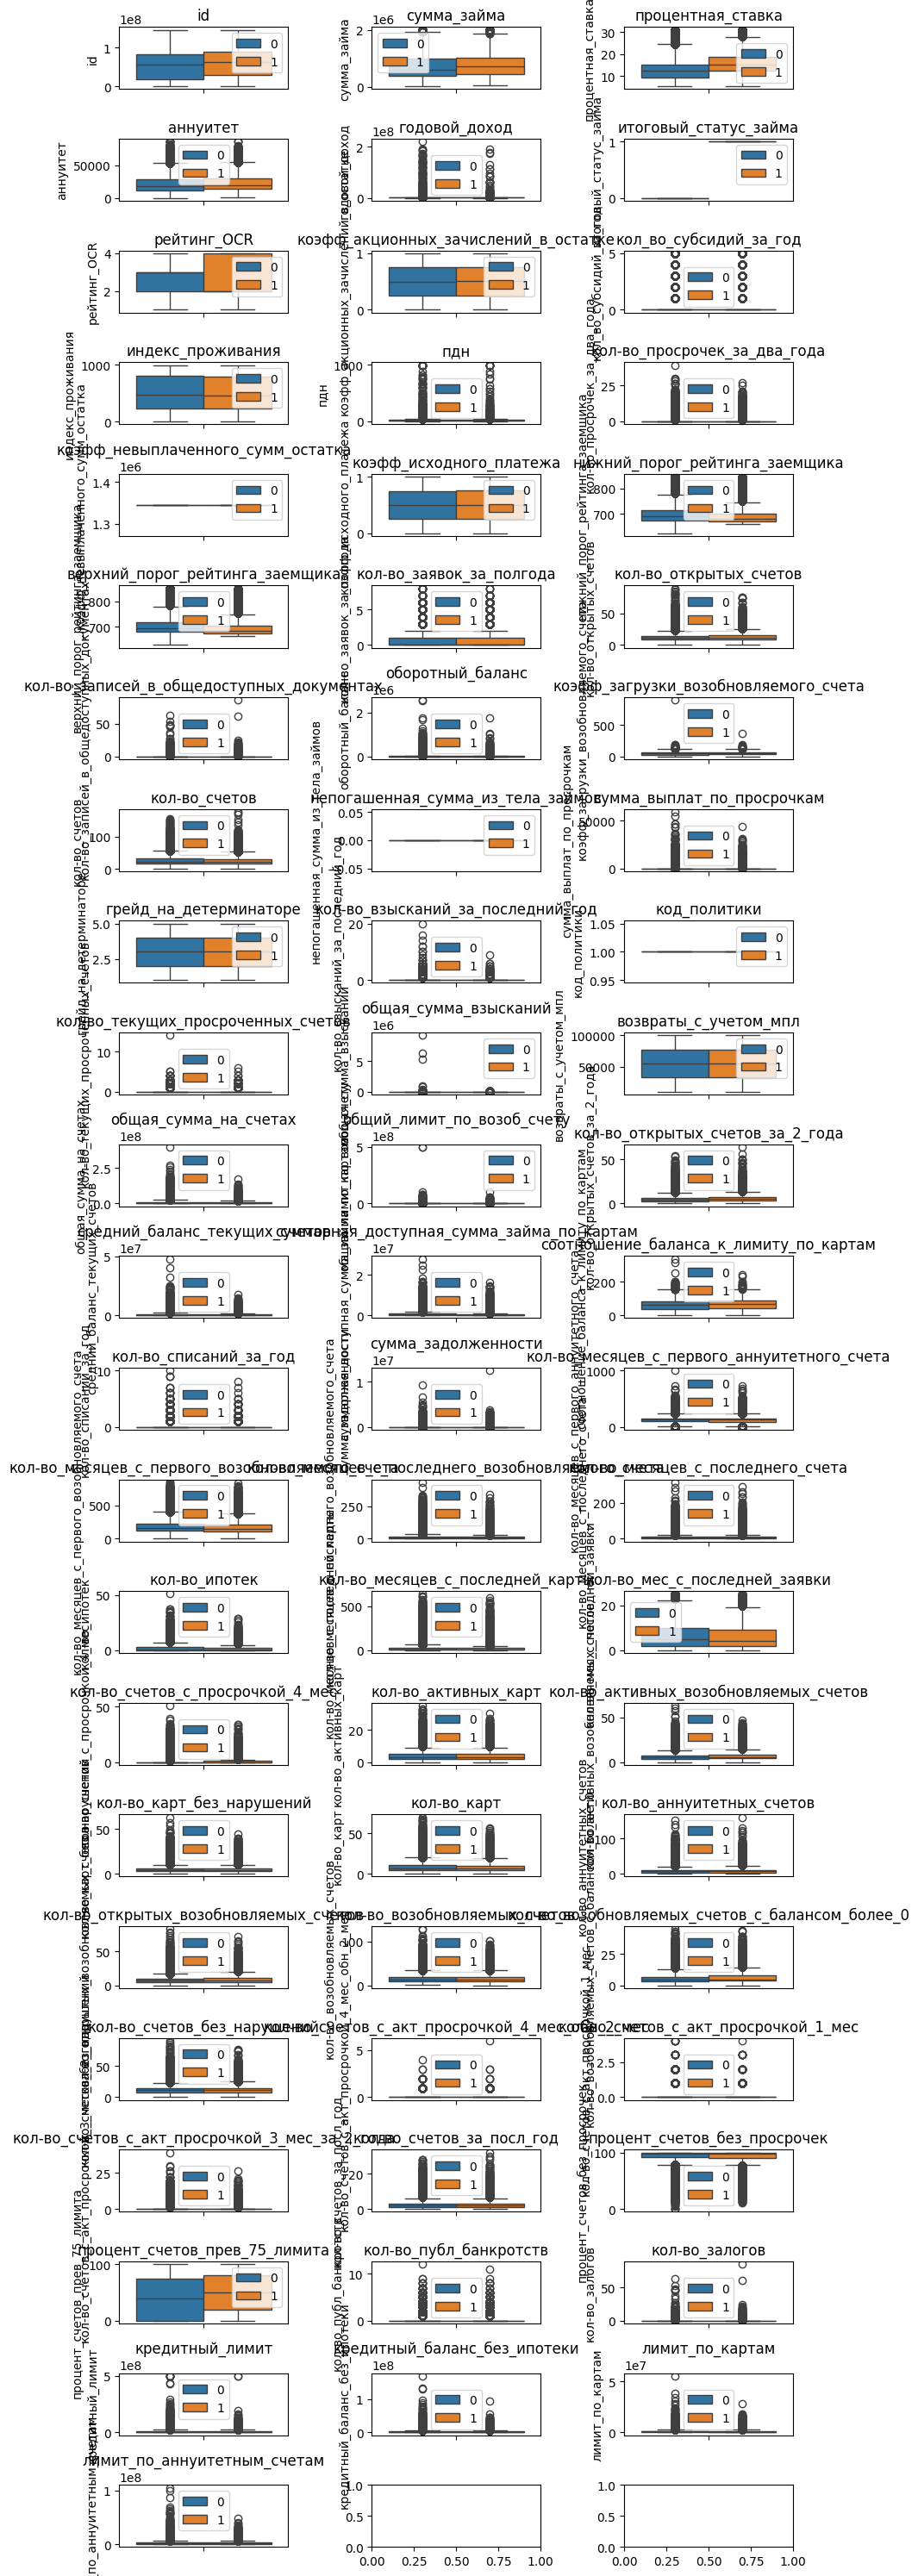

In [ ]:
n_cols = 3

cols_num = list(df_train[cols_to_keep].select_dtypes(exclude='object').columns)
cols_str = list(df_train[cols_to_keep].select_dtypes(include='object').columns)

df_filtr = df_train[cols_num].copy()
n_rows = math.ceil(len(df_filtr[cols_num].columns) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(9, 30))
axes = axes.flatten()

for i, column in enumerate(df_filtr.columns):
    sns.boxplot(df_train, y = column, hue = 'итоговый_статус_займа',ax=axes[i])
    axes[i].set_title(column)
    axes[i].legend()

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_8740\3725135714.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()
C:\Users\User\AppData\Local\Temp\ipykernel_8740\3725135714.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()
C:\Users\User\AppData\Local\Temp\ipykernel_8740\3725135714.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()
C:\Users\User\AppData\Local\Temp\ipykernel_8740\3725135714.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

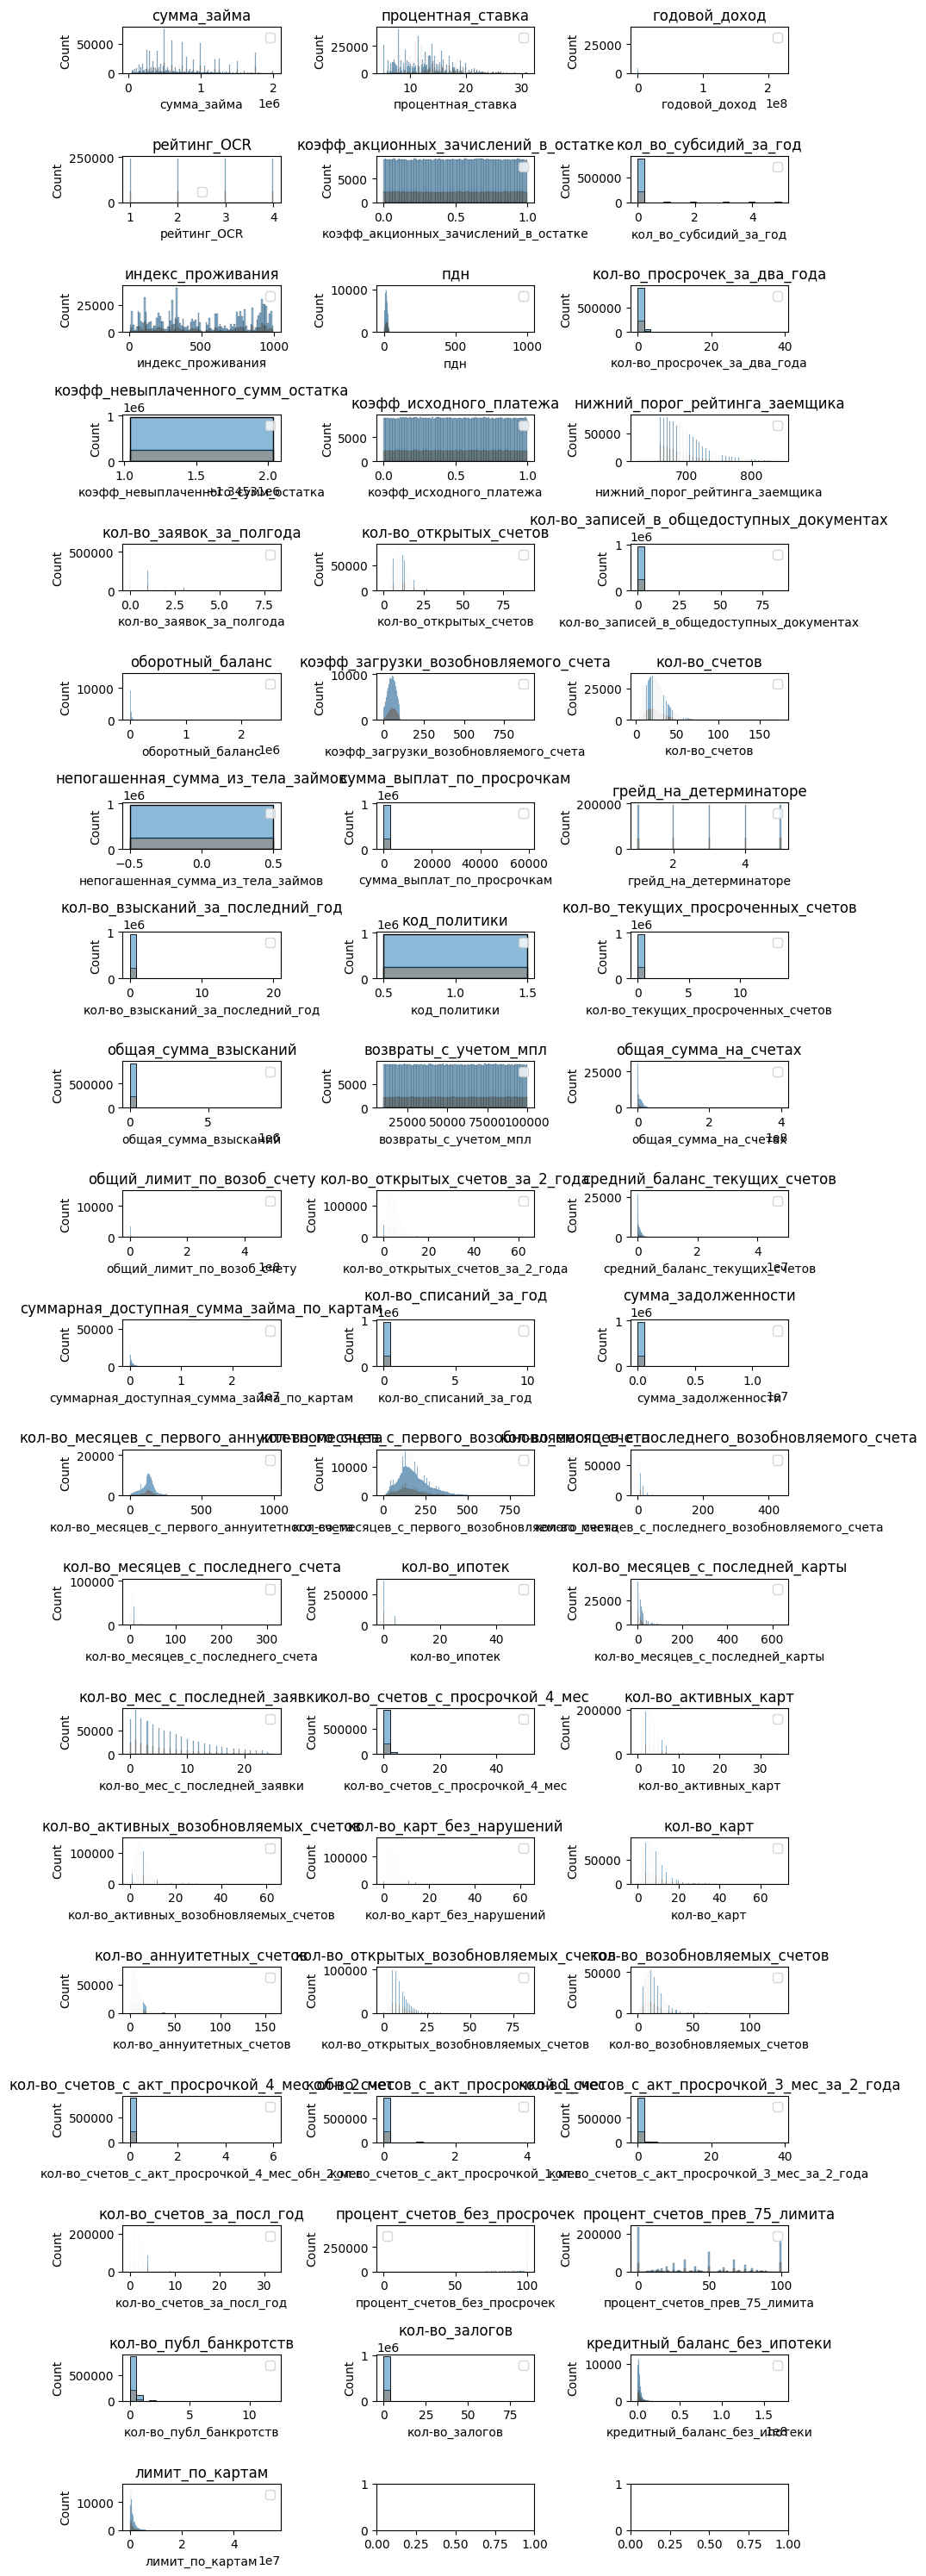

In [ ]:
n_cols = 3

to_keep = x_cols + ['итоговый_статус_займа']
df_filtr = df_train[cols_num].copy()
n_rows = math.ceil(len(df_filtr.columns) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(9, 30))
axes = axes.flatten()

for i, column in enumerate(df_filtr.columns):
    sns.histplot(df_train, x = column, hue = 'итоговый_статус_займа',ax=axes[i])
    axes[i].set_title(column)
    axes[i].legend()

plt.tight_layout()
plt.show()

### Предобработка данных

Предобработка включала в себя: 
1. Отбор признаков. Исключение колонок по критериям: большие пропуски (> 50%), дисбаланс категорий (одна категория составляет > 90% всех данных) и высокая корреляция (> 0.95). 
2. Сплит X, y в соотношеннии 80/20
3. Обработка колонок. Стаж: преобразование в год. Профессия_заемщика: кодирование профессий, встречающихся разово '1', пропуски '0', затем TargetEncoding для перевода в числовой вид в связи с большим числом категорий (276167).
4. Обработка числовых пропусков медианной, категориальных модой в зависимости от target

In [8]:
df_cat = pd.DataFrame()
cols_str = list(df_all.select_dtypes(include='object').columns)

for i in range(len(cols_str)):
    temp = df_all[cols_str[i]].value_counts().reset_index()
    temp['feature'] = cols_str[i]
    temp['percentage'] = round(temp['count']/df_train.shape[0], 2)
    temp.columns = ['value','count', 'feature', 'percentage']
    df_cat = pd.concat([df_cat, temp])
    print(cols_str[i], df_all[cols_str[i]].nunique())

high_imbalance = df_cat[df_cat['percentage'] >= 0.9]['feature'].to_list()
print('Колонки с высоким дисбалансом классов',high_imbalance)

срок_займа 2
рейтинг 7
допрейтинг 35
профессия_заемщика 276167
стаж 11
владение_жильем 6
подтвержден_ли_доход 3
платежный_график 1
цель_займа 14
регион 51
пос_стоп_фактор 3
юридический_статус 2
дата_первого_займа 736
первоначальный_статус_займа 2
пени_за_дефолт 2
тип_займа 2
совокупный_статус_подтверждения_доходов_заемщиков 3
особая_ситуация 1
тип_предоставления_кредита 2
Колонки с высоким дисбалансом классов ['платежный_график', 'пос_стоп_фактор', 'тип_займа', 'особая_ситуация', 'тип_предоставления_кредита']


In [57]:
df_cat[(df_cat['feature'] == 'профессия_заемщика')]['count'].describe(percentiles=[0.05,0.5,0.95])

,count
count,276167.000000
mean,4.416809
std,107.653732
min,1.000000
5%,1.000000
50%,1.000000
95%,6.000000
max,25809.000000


<Axes: >

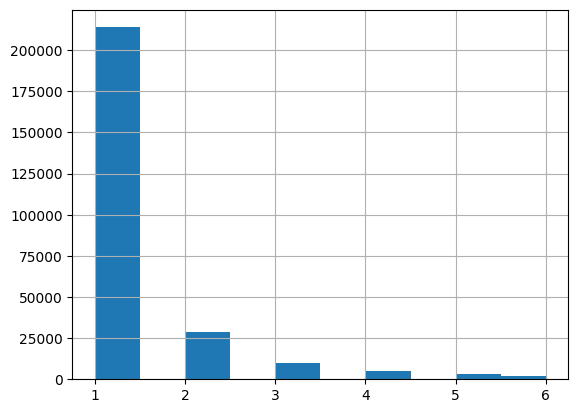

In [34]:
df_cat[(df_cat['feature'] == 'профессия_заемщика') & (df_cat['count'] <= 6)]['count'].hist()

Наибольшее число профессий встречаются разово, следовательно, их можно закодировать одним именем '1'. Пропуски в колонке с профессиями кодируем '0'.

#### Feature engineering

In [9]:
prof_list1 = set(df_cat[(df_cat['feature'] == 'профессия_заемщика') & (df_cat['count'] == 1)]['value'].to_list())
df_all['профессия_заемщика'] = df_all['профессия_заемщика'].fillna('0')
df_all['профессия_upd'] = pd.Series(['1' if x in prof_list1 else x for x in df_all['профессия_заемщика']])
df_all['стаж'] = df_all['стаж'].str.split(expand=True).iloc[:,0].copy()
df_all['стаж_num'] = df_all.apply(lambda x: int(x['стаж']) if type(pd.to_numeric(x['стаж'], errors='coerce')) == np.int64 else \
               10 if x['стаж'] == '10+' else 0.5 if x['стаж'] == '<' else 0, axis=1)
df_all['дата_первого_займа'] = pd.to_numeric(df_all['дата_первого_займа'].str[-4:])

In [ ]:
df_filtr = df_all.copy()
to_drop = ['id','итоговый_статус_займа','стаж','профессия_заемщика','Test'] + high_imbalance + corr_drop

x_cols = [item for item in cols_to_keep if item not in to_drop] + ['профессия_upd', 'стаж_num']
df_test = df_filtr[df_filtr['Test'] == 1][x_cols].reset_index(drop=True)
X_upd = df_filtr[df_filtr['Test'] != 1][x_cols]
y_upd = df_filtr[df_filtr['Test'] != 1]['итоговый_статус_займа']

X_train, X_valid, y_train, y_valid = train_test_split(X_upd, y_upd, test_size=0.2, random_state=42, stratify=y_upd)

# TargetEncoding профессии_заемщика

target_enc = TargetEncoder(random_state=42)
enc_train = target_enc.fit_transform(X_train[['профессия_upd']], y_train)
enc_valid = target_enc.transform(X_valid[['профессия_upd']])
enc_test = target_enc.transform(df_test[['профессия_upd']])

X_train.reset_index(drop=True, inplace=True)
X_valid.reset_index(drop=True, inplace=True)

X_train['профессия_enc'] = pd.Series(enc_train.flatten())
X_valid['профессия_enc'] = pd.Series(enc_valid.flatten())
df_test['профессия_enc'] = pd.Series(enc_test.flatten())
X_train.drop(columns='профессия_upd',inplace=True)
x_cols = X_train.columns.to_list()

df_train_x = X_train.copy()
df_train_x['target'] = y_train
df_valid = X_valid.copy()
df_valid['target'] = y_valid

cols_num = list(df_train_x.select_dtypes(exclude='object').columns)
cols_str = list(df_train_x.select_dtypes(include='object').columns)

df_num = df_train_x.groupby('target',as_index=False)[cols_num].median(numeric_only=True)
df_str = df_train_x.groupby('target',as_index=False)[cols_str].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
df_g = pd.merge(df_num, df_str, on = 'target')

# Обработка числовых пропусков медианной, категориальных модой в зависимости от target

category_dict = {category: group.drop('target', axis=1) 
                 for category, group in df_g.groupby('target')}

category_full_dict = {}
for category, group in df_g.groupby('target'):
    group_dict = group.drop('target', axis=1).to_dict('records')[0]
    category_full_dict[category] = group_dict

def fill_by_complex_dict(df, fill_dict):
    df_filled = df.copy()
    
    for category, col_dict in fill_dict.items():
        mask = df_filled['target'] == category
        
        for col, fill_value in col_dict.items():
            if col in df_filled.columns:
                col_mask = mask & df_filled[col].isnull()
                df_filled.loc[col_mask, col] = fill_value
    
    return df_filled

res_train = fill_by_complex_dict(df_train_x, category_full_dict)
res_valid = fill_by_complex_dict(df_valid, category_full_dict)

cols_num_xy = list(df_train_x.select_dtypes(exclude='object').columns)
cols_str = list(df_train_x.select_dtypes(include='object').columns)
cols_num = [item for item in cols_num_xy if item not in ['target']]

imputer_num = SimpleImputer(strategy='median')
imputer_num.fit(df_train_x[cols_num])
imputer_str = SimpleImputer(strategy='most_frequent')
imputer_str.fit(df_train_x[cols_str])


df_test[cols_num] = imputer_num.transform(df_test[cols_num])
df_test[cols_str] = imputer_str.transform(df_test[cols_str])

X_train = res_train[x_cols]
X_valid = res_valid[x_cols]
X_test = df_test[x_cols]

/tmp/ipython-input-916163506.py:60: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '54902.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_filled.loc[col_mask, col] = fill_value
/tmp/ipython-input-916163506.py:60: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '54902.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_filled.loc[col_mask, col] = fill_value


#### Catboost model

In [ ]:
def objective(trial):
    
    params = {
        'iterations': trial.suggest_int('iterations', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5, log=True),
        'depth': trial.suggest_int('depth', 5, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'random_strength': trial.suggest_float('random_strength', 0.1, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'grow_policy': trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise']),
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'verbose': False,
        'random_seed': 42,
        'task_type': 'GPU',
        'auto_class_weights': trial.suggest_categorical('auto_class_weights', ['Balanced', 'SqrtBalanced'])
    }
    

    model = CatBoostClassifier(**params)
    
    model.fit(
        X_train, y_train,
        eval_set=(X_valid, y_valid),
        early_stopping_rounds=50,
        verbose=False,
        cat_features=cols_str
    )
    
    y_val_pred = model.predict_proba(X_valid)[:, 1]
    val_score = roc_auc_score(y_valid, y_val_pred)
    
    trial.set_user_attr('model', model)
    
    return val_score


study = optuna.create_study(
    direction='maximize',
    study_name='catboost_hyperparams',
    storage=None, 
    load_if_exists=False,
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)
)


study.optimize(objective, n_trials=50, timeout=3600)

print(f'Best validation AUC: {study.best_value:.4f}')
print(f'Best params: {study.best_params}')

[I 2026-02-09 12:56:28,811] A new study created in memory with name: catboost_hyperparams
Default metric period is 5 because AUC is/are not implemented for GPU
[I 2026-02-09 12:57:22,011] Trial 0 finished with value: 0.7541674255653088 and parameters: {'iterations': 480, 'learning_rate': 0.04919893750421544, 'depth': 5, 'l2_leaf_reg': 7.123474847983067, 'random_strength': 5.987633240858712, 'bagging_temperature': 0.18575508970213395, 'border_count': 79, 'grow_policy': 'SymmetricTree', 'auto_class_weights': 'Balanced'}. Best is trial 0 with value: 0.7541674255653088.
Default metric period is 5 because AUC is/are not implemented for GPU
[I 2026-02-09 12:57:48,199] Trial 1 finished with value: 0.7487245210947137 and parameters: {'iterations': 186, 'learning_rate': 0.025147574392382823, 'depth': 10, 'l2_leaf_reg': 9.7003076289479, 'random_strength': 4.429396880776194, 'bagging_temperature': 0.36357206311938406, 'border_count': 187, 'grow_policy': 'SymmetricTree', 'auto_class_weights': 'Bal

Best validation AUC: 0.7592
Best params: {'iterations': 423, 'learning_rate': 0.11296183714058523, 'depth': 5, 'l2_leaf_reg': 2.0718060453463734, 'random_strength': 5.150015462599627, 'bagging_temperature': 0.062133050141008464, 'border_count': 83, 'grow_policy': 'Depthwise', 'auto_class_weights': 'SqrtBalanced'}


In [ ]:
# params = study.best_params
params = {'iterations': 423,
    'learning_rate': 0.11296183714058523,
    'depth': 5,
    'l2_leaf_reg': 2.0718060453463734,
    'random_strength': 5.150015462599627,
    'bagging_temperature': 0.062133050141008464,
    'border_count': 83,
    'grow_policy': 'Depthwise',
    'auto_class_weights': 'SqrtBalanced'}

params['verbose'] = False
params['random_state'] = 42
params['task_type'] = 'GPU'
params['has_time'] = False

clf_catboost = CatBoostClassifier(**params)
clf_catboost.fit(X_train, y_train, cat_features=cols_str)
y_tp_c = clf_catboost.predict_proba(X_train)[:, 1]
y_vp_c = clf_catboost.predict_proba(X_valid)[:, 1]

print(
    f'Train: {roc_auc_score(y_train, y_tp_c)}\n'
    f'valid: {roc_auc_score(y_valid, y_vp_c)}\n'
)

# Предсказание вероятностей
probabilities = clf_catboost.predict_proba(X_test)[:, 1]

Train: 0.779189164164001
valid: 0.7615260611159645



In [56]:
# Формируем сабмит
answer = pd.DataFrame()
answer['id'] = X_test_base['id']
answer['proba'] = probabilities

drive_path = '/content/drive/My Drive/Colab Notebooks/submission.csv'
csv_path = os.path.join(drive_path)
answer.to_csv(csv_path, index=False, encoding='utf-8')

In [ ]:
%pip freeze > /content/requirements.txt
%pip freeze > '/content/drive/My Drive/Colab Notebooks/requirements.txt'

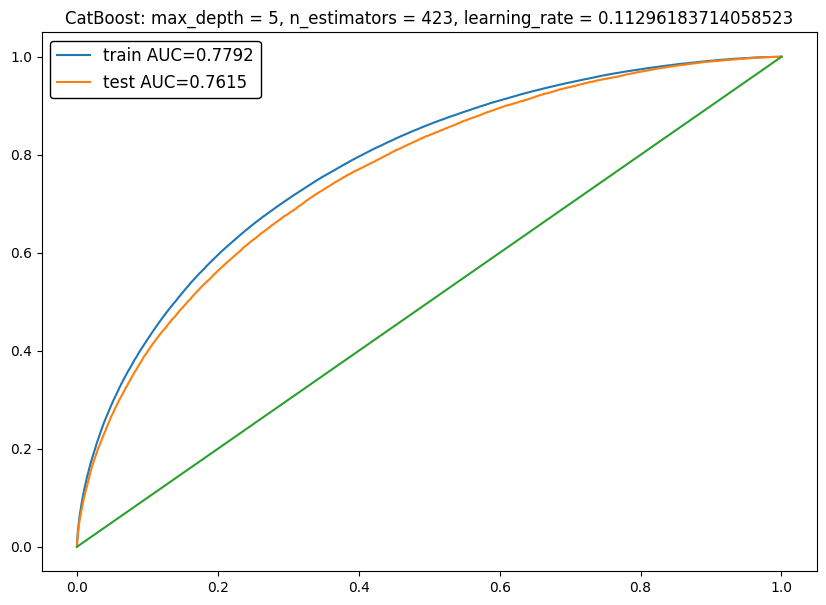

In [58]:
y_train_pred = y_tp_c
y_valid_pred = y_vp_c
train_auc = roc_auc_score(y_train, y_train_pred)
test_auc = roc_auc_score(y_valid, y_valid_pred)

plt.figure(figsize=(10,7))
plt.plot(*roc_curve(y_train, y_train_pred)[:2], label='train AUC={:.4f}'.format(train_auc))
plt.plot(*roc_curve(y_valid, y_valid_pred)[:2], label='test AUC={:.4f}'.format(test_auc))
legend_box = plt.legend(fontsize='large', framealpha=1).get_frame()
legend_box.set_facecolor("white")
legend_box.set_edgecolor("black")
plt.plot(np.linspace(0,1,100), np.linspace(0,1,100))
plt.title(f'CatBoost: max_depth = {params['depth']}, n_estimators = {params['iterations']}, learning_rate = {params['learning_rate']}')
plt.show()

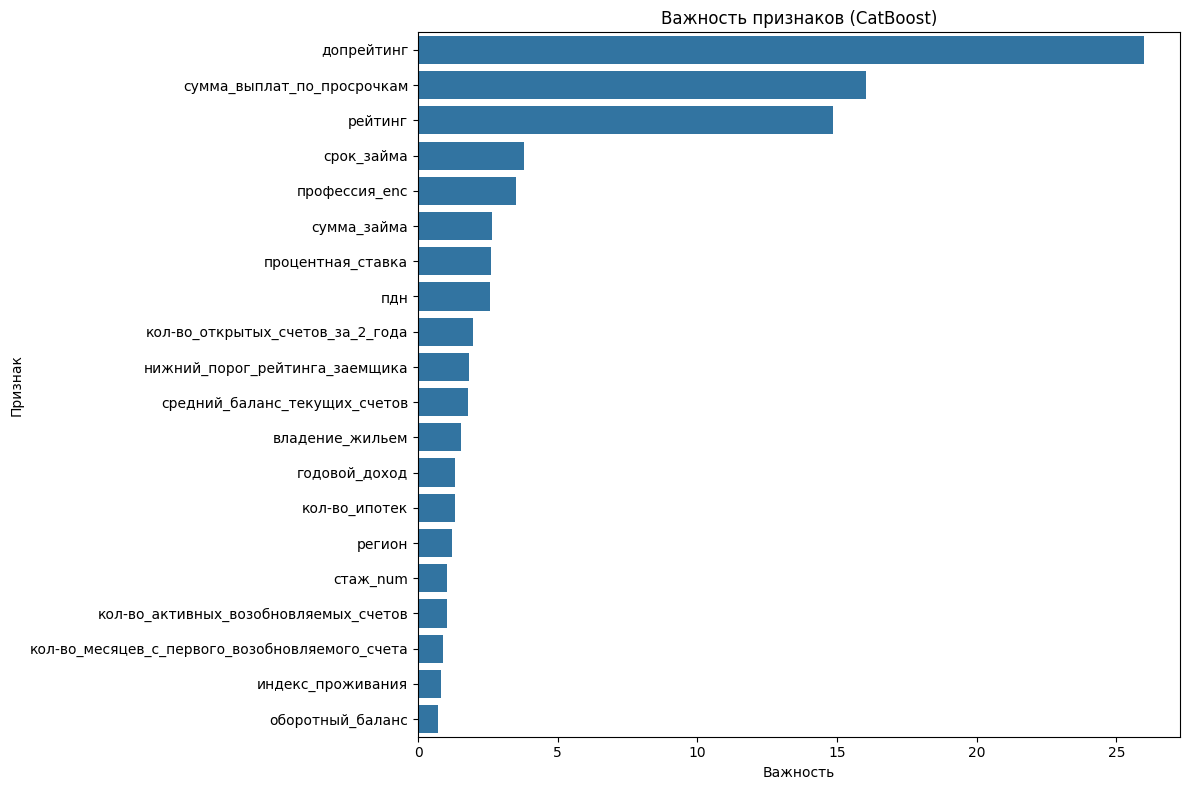

In [52]:
# Получение важности признаков
feature_importances = clf_catboost.get_feature_importance()
feature_names = x_cols

# Создание DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

# Визуализация
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20))
plt.title('Важность признаков (CatBoost)')
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

Из графика влияния параметров модели на принятие решения по выдаче кредита наибольшей степенью обладают признаки: допрейтинг, сумма_выплат_по_просрочкам, рейтинг. Далее: срок_займа, профессия (TargetEncoding), сумма_займа.  
Признаки с наименьшей степенью влияния < 0.1 имеет смысл исключить и перестроить модель для оценки ее качества.

In [53]:
importance_df[importance_df.Importance < 0.1]

,Feature,Importance
61,кол-во_счетов_с_акт_просрочкой_3_мес_за_2_года,0.075234
59,кол-во_счетов_с_акт_просрочкой_4_мес_обн_2_мес,0.067931
66,кол-во_залогов,0.062227
43,сумма_задолженности,0.050500
31,кол-во_взысканий_за_последний_год,0.046359
30,грейд_на_детерминаторе,0.044188
11,кол_во_субсидий_за_год,0.032429
8,рейтинг_OCR,0.028555
42,кол-во_списаний_за_год,0.020980
60,кол-во_счетов_с_акт_просрочкой_1_мес,0.017715


In [54]:
# Функция для оценки модели
def evaluate_model(model, X_train, X_valid, y_train, y_valid, cat_f):
    model.fit(X_train, y_train, cat_features = cat_f)
    y_tp_c = model.predict_proba(X_train)[:, 1]
    y_vp_c = model.predict_proba(X_valid)[:, 1]
    ROC_AUC_p = roc_auc_score(y_train, y_tp_c)
    ROC_AUC_v = roc_auc_score(y_valid, y_vp_c)
    return ROC_AUC_p, ROC_AUC_v

In [55]:
to_keep = importance_df[importance_df.Importance > 0.1].Feature.to_list()
X_train_imp = X_train[to_keep]
X_valid_imp = X_valid[to_keep]
X_test_imp = X_test[to_keep]

new_str = X_train_imp.select_dtypes(include='object').columns.to_list()

roc_auc_train, roc_auc_valid = evaluate_model(clf_catboost, X_train_imp, X_valid_imp, y_train, y_valid, new_str)

print(
    f'ROC-AUC Train: {roc_auc_train}\n'
    f'ROC-AUC Valid: {roc_auc_valid}\n'
)

# probabilities = clf_catboost.predict_proba(X_test_imp)[:, 1]

ROC-AUC Train: 0.7789723860602306
ROC-AUC Valid: 0.7612284552036722



Качество незначительно изменилось. Было: Train - 0.779189164164001, valid - 0.7615260611159645. Следовательно, исходное решение можно использовать в качестве финального.

#### Выводы

* Для решения задачи была построена модель классификации CatBoost.
* С помощью пакета optuna был определен набор параметров модели, при котором получен наибольший ROC-AUC valid = 0.7589 (ROC-AUC train = 0.7785).   
Параметры = {'iterations': 423,
    'learning_rate': 0.11296183714058523,
    'depth': 5,
    'l2_leaf_reg': 2.0718060453463734,
    'random_strength': 5.150015462599627,
    'bagging_temperature': 0.062133050141008464,
    'border_count': 83,
    'grow_policy': 'Depthwise',
    'auto_class_weights': 'SqrtBalanced'}
* Стоит отметить, что вышеописанные метрики ROC-AUC были получены на версии модели, где среди признаков не было тех, у которых корреляция > 0.85. У актуальной модели, где метрики ROC-AUC составили: Train - 0.779189164164001, valid - 0.7615260611159645, были исключены признаки с корреляцией > 0.95. 
* Наибольшей степенью влияния на принятие решения по выдаче кредита обладают признаки: допрейтинг, сумма_выплат_по_просрочкам, рейтинг, срок_займа, профессия (TargetEncoding). Далее: срок_займа, профессия (TargetEncoding), сумма_займа.